In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report)

In [2]:
# 1. Dataset Loading and Preprocessing
iris = load_iris()
X,y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Split dataset (70% Train, 30% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
# 2. Default SVM Model Training
default_svm = SVC(kernel='rbf', C=1.0, gamma='scale', decision_function_shape='ovr', random_state=42)
default_svm.fit(X_train_scaled, y_train)
y_pred_default = default_svm.predict(X_test_scaled)

print(f"Default SVM Accuracy: {accuracy_score(y_test, y_pred_default):.4f}\n")

Default SVM Accuracy: 1.0000



In [5]:
print(f"Default SVM Model Evaluation\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Precision (Macro): {precision_score(y_test, y_pred_default, average='macro'):.4f}")
print(f"Recall (Macro): {recall_score(y_test, y_pred_default, average='macro'):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred_default, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default, target_names=target_names))

Default SVM Model Evaluation

Accuracy: 1.0000
Precision (Macro): 1.0000
Recall (Macro): 1.0000
F1-Score (Macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



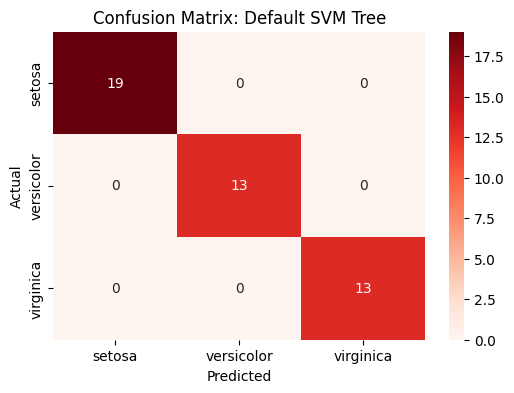

In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_default)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Default SVM Tree')
plt.show()

Hyperparameters Tuning

In [7]:
kernels = ['linear', 'poly', 'rbf']
C_values = [0.1, 1, 10]
gammas = ['scale', 'auto']

In [8]:
best_score = 0
best_params = {}

In [9]:
print("SVM Hyperparameter Tuning Results\n")
for k in kernels:
    for c in C_values:
        for g in gammas:
            # Note: decision_function_shape='ovo' as requested
            svc = SVC(kernel=k, C=c, gamma=g, decision_function_shape='ovo', random_state=42)
            svc.fit(X_train_scaled, y_train)
            score = accuracy_score(y_test, svc.predict(X_test_scaled))

            print(f"Kernel: {k:6} | C: {c:3} | Gamma: {g:5} | Accuracy: {score:.4f}")

            if score > best_score:
                best_score = score
                best_params = {'kernel': k, 'C': c, 'gamma': g}

print(f"\nBest Parameters: {best_params} with Accuracy: {best_score:.4f}")

SVM Hyperparameter Tuning Results

Kernel: linear | C: 0.1 | Gamma: scale | Accuracy: 1.0000
Kernel: linear | C: 0.1 | Gamma: auto  | Accuracy: 1.0000
Kernel: linear | C:   1 | Gamma: scale | Accuracy: 0.9778
Kernel: linear | C:   1 | Gamma: auto  | Accuracy: 0.9778
Kernel: linear | C:  10 | Gamma: scale | Accuracy: 0.9778
Kernel: linear | C:  10 | Gamma: auto  | Accuracy: 0.9778
Kernel: poly   | C: 0.1 | Gamma: scale | Accuracy: 0.8444
Kernel: poly   | C: 0.1 | Gamma: auto  | Accuracy: 0.8444
Kernel: poly   | C:   1 | Gamma: scale | Accuracy: 0.9556
Kernel: poly   | C:   1 | Gamma: auto  | Accuracy: 0.9556
Kernel: poly   | C:  10 | Gamma: scale | Accuracy: 0.9778
Kernel: poly   | C:  10 | Gamma: auto  | Accuracy: 0.9778
Kernel: rbf    | C: 0.1 | Gamma: scale | Accuracy: 0.9333
Kernel: rbf    | C: 0.1 | Gamma: auto  | Accuracy: 0.9333
Kernel: rbf    | C:   1 | Gamma: scale | Accuracy: 1.0000
Kernel: rbf    | C:   1 | Gamma: auto  | Accuracy: 1.0000
Kernel: rbf    | C:  10 | Gamma: scal

In [10]:
# 4. Model Evaluation (Best Model)
best_svm = SVC(**best_params, decision_function_shape='ovo', random_state=42)
best_svm.fit(X_train_scaled, y_train)
y_pred = best_svm.predict(X_test_scaled)

In [13]:
print("Final SVM Model Evaluation\n")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (Macro): {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (Macro): {recall_score(y_test, y_pred, average='macro'):.4f}")
print(f"F1-Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Final SVM Model Evaluation

Accuracy: 1.0000
Precision (Macro): 1.0000
Recall (Macro): 1.0000
F1-Score (Macro): 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



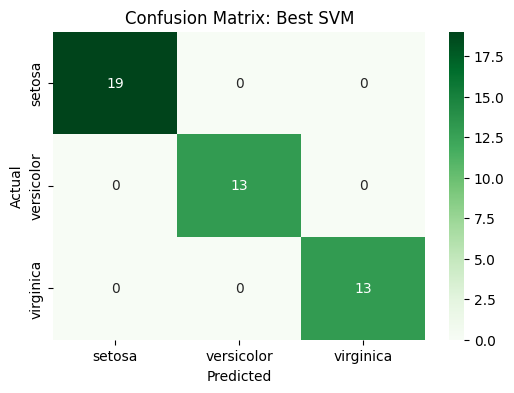

In [12]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Best SVM')
plt.show()